In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
pp_path ='data/ClimateScenarios/pr/pr_As_merged.nc'
pp = xr.open_dataset(pp_path)

tas_path ='data/ClimateScenarios/tas/tas_As_merged.nc'
tas = xr.open_dataset(tas_path)

In [3]:
# # Example: Select rcp 2.6 and plot time serie for each model_tag

# pp_rcp26 = pp.sel(rcp_tag='rcp26').mean(dim=['rlon', 'rlat']) # Mean value over lon and lat
# plt.figure(figsize=(15,6))
# for model in pp_rcp26['model_tag'].values:
#     pp_rcp26.sel(model_tag=model)['pr'].plot(label=model,alpha=0.5)
# plt.title('Precipitation time series for RCP 2.6')
# plt.ylabel('Precipitation (mm/day)')
# plt.xlabel('Time')

In [4]:
# # Example: Calculate and plot the mean precipitation map averaged across models and scenarios

# test = pp['pr'].mean(dim=['time', 'model_tag', 'rcp_tag']) * 86400  # Convertir a mm/day
# test.plot(
#     x='rlon', y='rlat',
#     cmap='Blues',
#     cbar_kwargs={'label': 'Mean Precipitation (mm/day)'},
#     robust=True
# )
# plt.title('Mean Precipitation (averaged across models and scenarios)')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

### Estimate seasonal weighted steps for the sensivity analysis - Temperature
Follow the method of Supplementary Material of https://doi.org/10.1016/j.agrformet.2018.10.006 

#### 1. Temperature

In [3]:
# Function to map month to season
def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"   # Winter
    elif month in [3, 4, 5]:
        return "MAM"   # Spring
    elif month in [6, 7, 8]:
        return "JJA"   # Summer
    else:
        return "SON"   # Autumn

# Define all future periods
periods = [
    ("2001-01-01","2029-12-31"),
    ("2011-01-01","2039-12-31"),
    ("2021-01-01","2049-12-31"),
    ("2031-01-01","2059-12-31"),
    ("2041-01-01","2069-12-31"),
    ("2051-01-01","2079-12-31"),
    ("2061-01-01","2089-12-31"),
    ("2071-01-01","2099-12-31"),
]

# Define baseline period
baseline_period = ('1991-01-01','2019-12-31')

# Define last period
last_period = ('2071-01-01','2099-12-31')



In [4]:
################## rcp85 2071-2099 ##################
tas_rcp85 = tas.sel(rcp_tag='rcp85').mean(dim=['model_tag','rlon','rlat'])
data = tas_rcp85['tas'] - 273.15
data = data.to_dataframe().reset_index().dropna(subset=["tas"])

# Add year and month
data["year"] = data["time"].dt.year
data["month"] = data["time"].dt.month

# --- Annual means (one value per year) ---
annual_means = (
    data.groupby(["year","rcp_tag"])["tas"]
    .mean()
    .reset_index()
)
annual_means["season"] = "Annual"
annual_means["time"] = pd.to_datetime(annual_means["year"].astype(str) + "-01-01")

# --- Seasonal means (one value per year per season) ---
# Define a "season_year" so DJF is grouped correctly
data["season_year"] = data["year"]
data.loc[data["month"] == 12, "season_year"] += 1  # December belongs to next year's DJF

def month_to_season(m):
    if m in [12,1,2]: return "DJF"
    elif m in [3,4,5]: return "MAM"
    elif m in [6,7,8]: return "JJA"
    elif m in [9,10,11]: return "SON"

data["season"] = data["month"].map(month_to_season)

seasonal_means = (
    data.groupby(["season_year","season","rcp_tag"])["tas"]
    .mean()
    .reset_index()
    .rename(columns={"season_year":"year"})
)
seasonal_means["time"] = pd.to_datetime(seasonal_means["year"].astype(str) + "-01-01")

# --- Combine annual + seasonal ---
data_means = pd.concat([annual_means, seasonal_means], ignore_index=True)

# --- Baseline climatology ---
start, end = baseline_period
baseline = data_means.query("time >= @start and time <= @end").copy()

seasonal_climatology = baseline.query("season != 'Annual'").groupby("season")["tas"].mean()
annual_climatology = baseline.query("season == 'Annual'")["tas"].mean()

# --- Last period anomalies ---
start, end = last_period
data_2071_2099 = data_means.query("time >= @start and time <= @end").copy()

def anomaly(row):
    if row["season"] == "Annual":
        return row["tas"] - annual_climatology
    else:
        return row["tas"] - seasonal_climatology.loc[row["season"]]

data_2071_2099["tas_change"] = data_2071_2099.apply(anomaly, axis=1)


################## all scenarios all periods ##################
tas_rcps = tas.mean(dim=['model_tag','rlon','rlat'])
data = tas_rcps['tas'] - 273.15
data = data.to_dataframe().reset_index().dropna(subset=["tas"])

# Add year and month
data["year"] = data["time"].dt.year
data["month"] = data["time"].dt.month

# --- Annual means (one value per year per scenario) ---
annual_means = (
    data.groupby(["year","rcp_tag"])["tas"]
    .mean()
    .reset_index()
)
annual_means["season"] = "Annual"
annual_means["time"] = pd.to_datetime(annual_means["year"].astype(str) + "-01-01")

# --- Seasonal means (one value per year per season) ---
# Shift December into next year's DJF
data["season_year"] = data["year"]
data.loc[data["month"] == 12, "season_year"] += 1

def month_to_season(m):
    if m in [12,1,2]: return "DJF"
    elif m in [3,4,5]: return "MAM"
    elif m in [6,7,8]: return "JJA"
    elif m in [9,10,11]: return "SON"

data["season"] = data["month"].map(month_to_season)

seasonal_means = (
    data.groupby(["season_year","season","rcp_tag"])["tas"]
    .mean()
    .reset_index()
    .rename(columns={"season_year":"year"})
)
seasonal_means["time"] = pd.to_datetime(seasonal_means["year"].astype(str) + "-01-01")

# --- Combine annual + seasonal ---
data_means = pd.concat([annual_means, seasonal_means], ignore_index=True)

# --- Baseline climatology ---
start, end = baseline_period
baseline = data_means.query("time >= @start and time <= @end").copy()

seasonal_climatology = baseline.query("season != 'Annual'").groupby("season")["tas"].mean()
annual_climatology = baseline.query("season == 'Annual'")["tas"].mean()

# --- Collect anomalies for each scenario and period ---
results = []
for start, end in periods:
    sub = data_means.query("time >= @start and time <= @end").copy()
    sub["tas_change"] = sub.apply(
        lambda row: row["tas"] - (annual_climatology if row["season"]=="Annual"
                                 else seasonal_climatology.loc[row["season"]]),
        axis=1
    )
    sub["period"] = f"{start[:4]}-{end[:4]}"
    results.append(sub)

all_data = pd.concat(results, ignore_index=True)

In [5]:
### Summary statistics for all RCPs and all periods 
# #CHECK THIS!!!
max_all = np.max(all_data[all_data['season'] == 'Annual']["tas_change"])
min_all = np.min(all_data[all_data['season'] == 'Annual']["tas_change"])

print(f"Maximum annual tas_change (all RCPs, all periods): {max_all:.2f} °C")
print(f"Minimum annual tas_change (all RCPs, all periods): {min_all:.2f} °C")

# Use the percentiles to define the steps range

Maximum annual tas_change (all RCPs, all periods): 5.21 °C
Minimum annual tas_change (all RCPs, all periods): -0.95 °C


In [7]:
#create dataframe with columns: 'annual','DJF','MAM','JJA','SON' and rows with the weighted steps 
weight_DJF = np.mean(data_2071_2099[data_2071_2099['season']=='DJF']['tas_change'])/np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['tas_change'])
weight_MAM = np.mean(data_2071_2099[data_2071_2099['season']=='MAM']['tas_change'])/np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['tas_change'])
weight_JJA = np.mean(data_2071_2099[data_2071_2099['season']=='JJA']['tas_change'])/np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['tas_change'])
weight_SON = np.mean(data_2071_2099[data_2071_2099['season']=='SON']['tas_change'])/np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['tas_change'])

steps_pos = pd.DataFrame({
    "Annual": np.arange(0, 6.0, 0.5),
    "DJF": np.round(np.arange(0, 6.0, 0.5)*weight_DJF,2),
    "MAM": np.round(np.arange(0, 6.0, 0.5)*weight_MAM,2),
    "JJA": np.round(np.arange(0, 6.0, 0.5)*weight_JJA,2),
    "SON": np.round(np.arange(0, 6.0, 0.5)*weight_SON,2)
})

steps_neg = pd.DataFrame({
    "Annual": np.arange(-1, 0, 0.5),
    "DJF": np.round(np.arange(-1, 0, 0.5) * weight_DJF * -1 + np.arange(-1, 0, 0.5) * 2 ,2),
    "MAM": np.round(np.arange(-1, 0, 0.5) * weight_MAM * -1 + np.arange(-1, 0, 0.5) * 2 ,2),
    "JJA": np.round(np.arange(-1, 0, 0.5) * weight_JJA * -1 + np.arange(-1, 0, 0.5) * 2 ,2),
    "SON": np.round(np.arange(-1, 0, 0.5) * weight_SON * -1 + np.arange(-1, 0, 0.5) * 2 ,2)
})

steps = pd.concat([steps_neg, steps_pos], ignore_index=True)
steps.to_excel('methodology_outs/tas_change_steps_weighted_seasons_JOK.xlsx', index=False)

In [8]:
steps

,Annual,DJF,MAM,JJA,SON
0,-1.0,-0.78,-1.07,-1.06,-1.09
1,-0.5,-0.39,-0.53,-0.53,-0.54
2,0.0,0.00,0.00,0.00,0.00
3,0.5,0.61,0.47,0.47,0.46
4,1.0,1.22,0.93,0.94,0.91
5,1.5,1.83,1.40,1.41,1.37
6,2.0,2.44,1.87,1.88,1.83
7,2.5,3.05,2.34,2.35,2.29
8,3.0,3.65,2.80,2.82,2.74
9,3.5,4.26,3.27,3.29,3.20


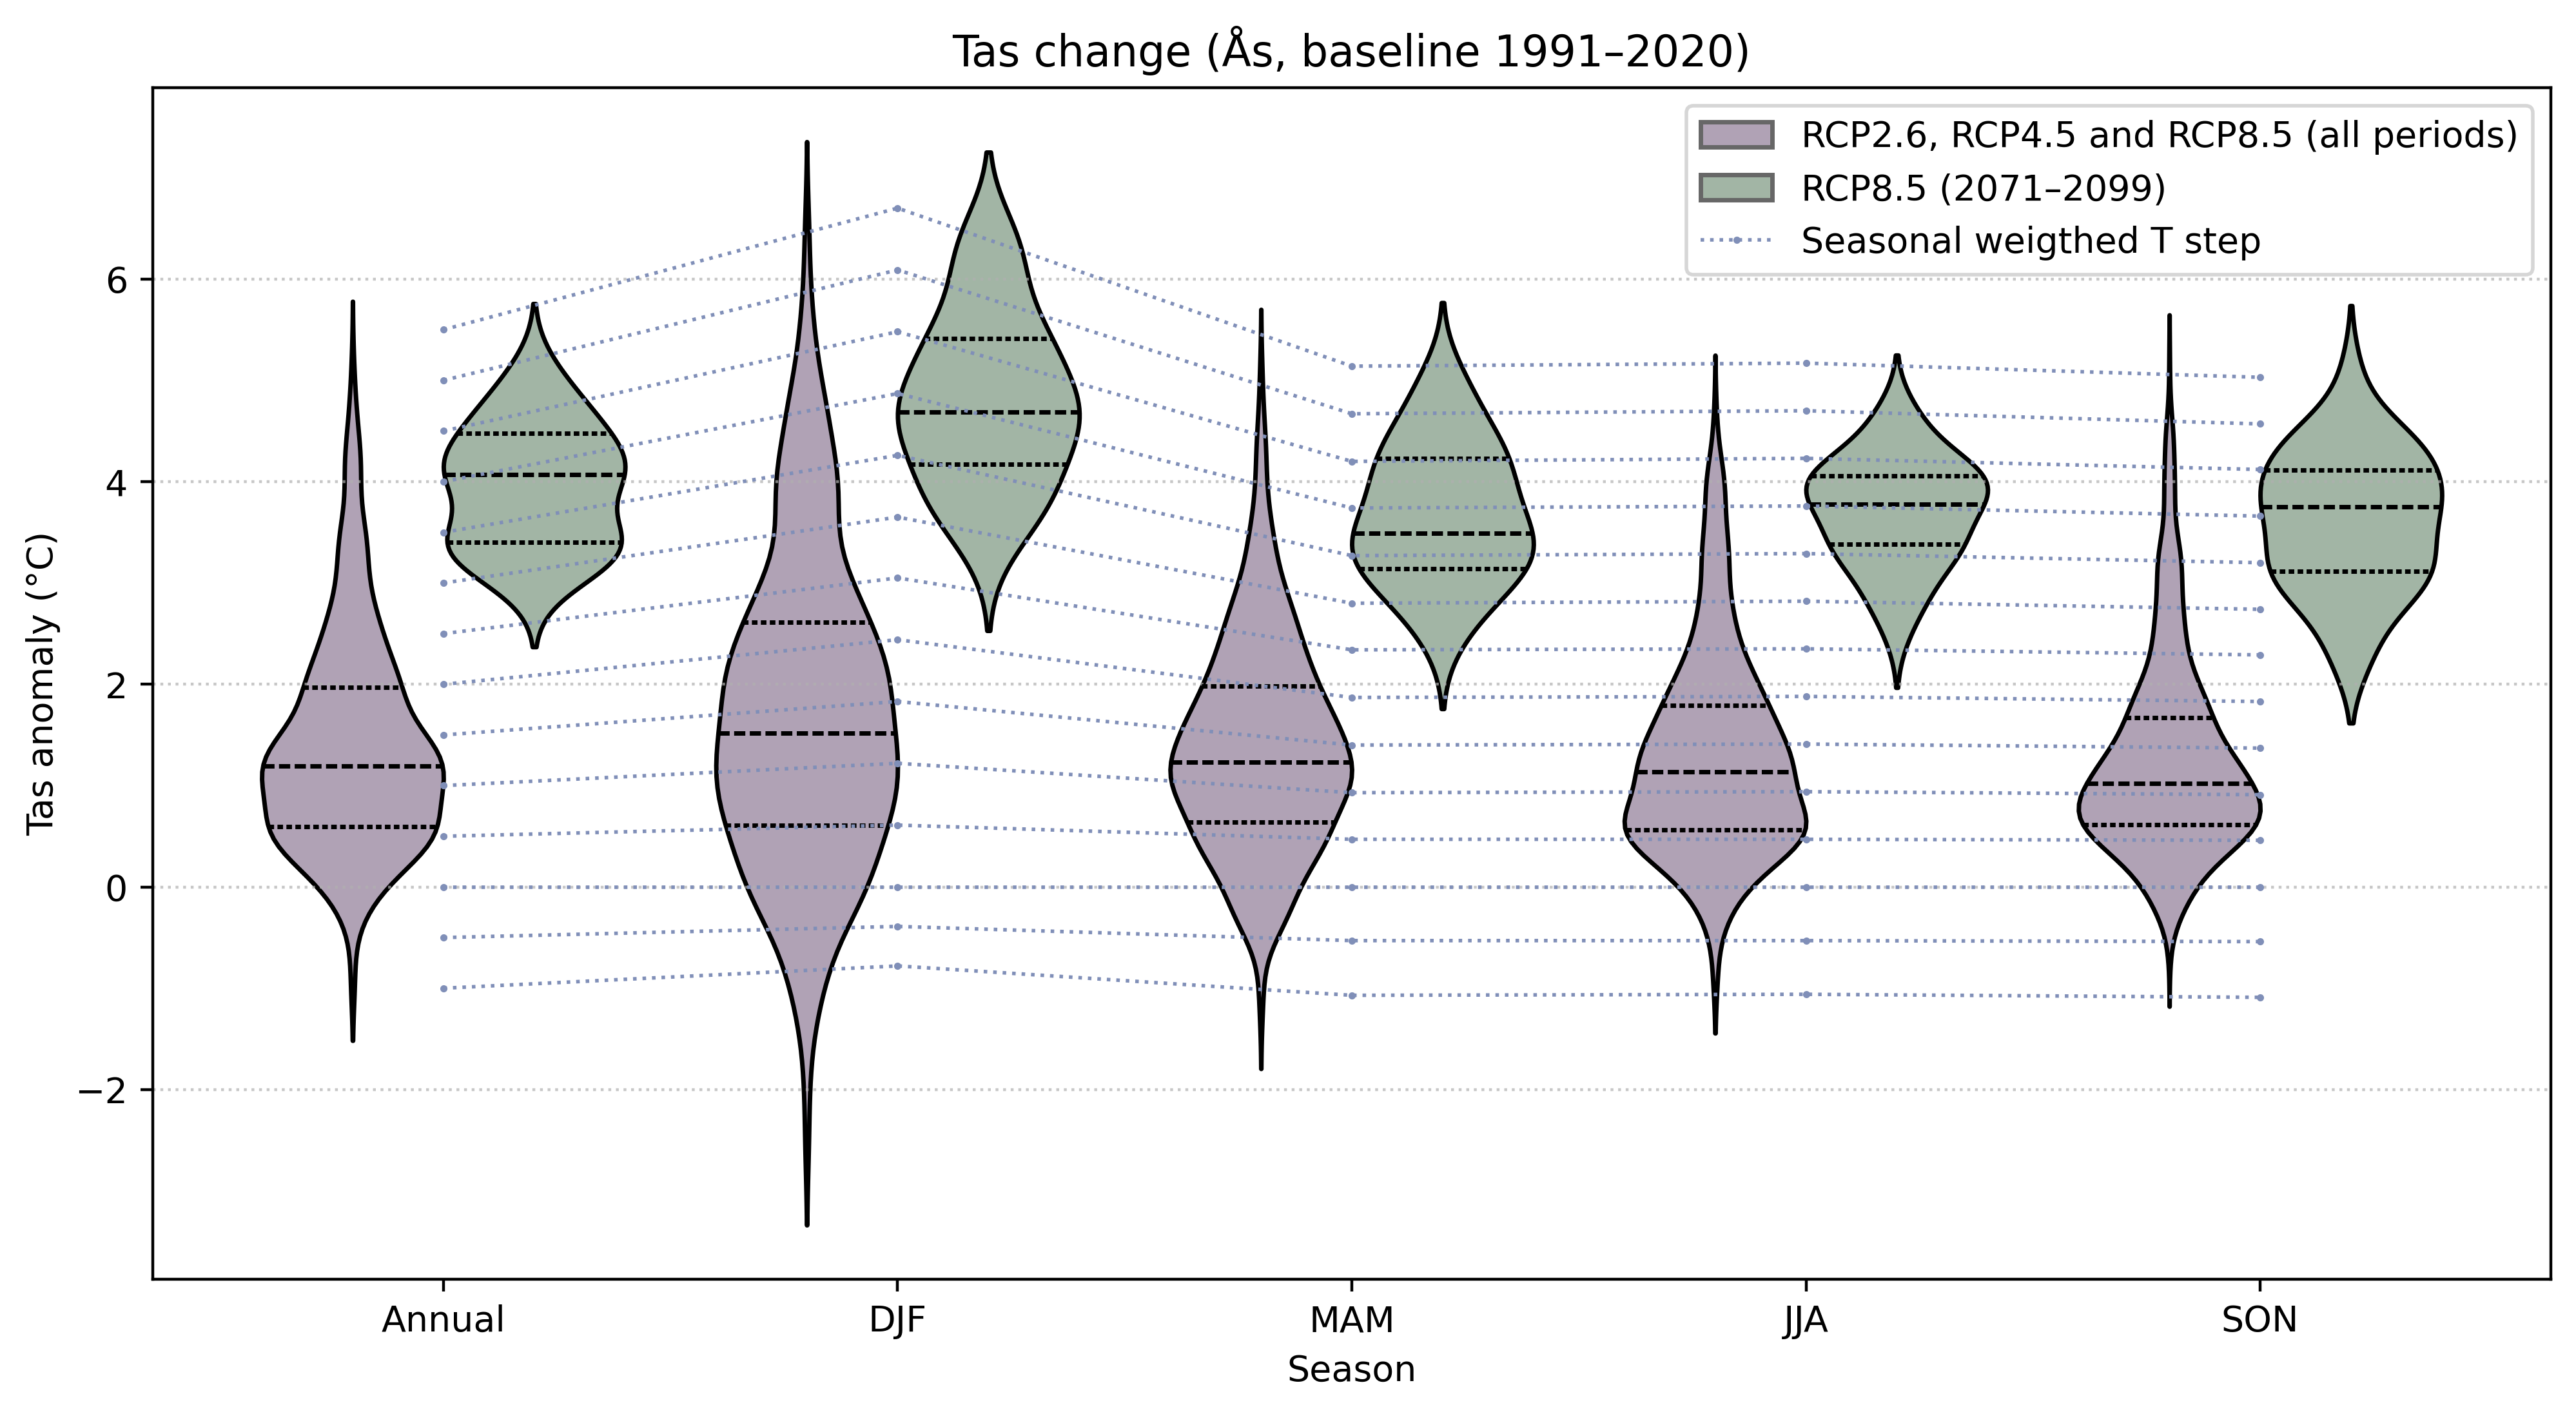

In [10]:
### plot
# Label each dataset
all_data_plot = all_data.copy()
all_data_plot["dataset"] = "RCP2.6, RCP4.5 and RCP8.5 (all periods)"

data_2071_2099_plot = data_2071_2099.copy()
data_2071_2099_plot["dataset"] = "RCP8.5 (2071–2099)"

# Combine
combined = pd.concat([all_data_plot, data_2071_2099_plot])

plt.figure(figsize=(12,6), dpi = 400)
plt.grid(linestyle=':', alpha=0.7)

ax = sns.violinplot( 
    x="season", y="tas_change", hue="dataset",
    data=combined,
    inner="quartile", density_norm="width",
    order=["Annual","DJF","MAM","JJA","SON"], 
    palette= ['#B29FB8', '#9FB8A3']
)

# Style borders and mean lines
for violin in ax.collections:
    violin.set_edgecolor("black")
for line in ax.lines:
    line.set_color("black")

season_order = ["Annual","DJF","MAM","JJA","SON"]
# Each row in steps is one "step index"
for idx, row in steps.iterrows():
    yvals = [row[season] for season in season_order]
    xvals = list(range(len(season_order)))  # [0,1,2,3,4]
    ax.plot(xvals, yvals, color='#808FB8', linewidth=1, linestyle = ':', marker="o", markersize=1, label = 'Seasonal weigthed T step' if idx == 0 else "")

plt.title("Tas change (Ås, baseline 1991–2020)")
plt.ylabel("Tas anomaly (°C)")
plt.xlabel("Season")
plt.legend(loc="best")
plt.show()

In [11]:
steps

,Annual,DJF,MAM,JJA,SON
0,-1.0,-0.78,-1.07,-1.06,-1.09
1,-0.5,-0.39,-0.53,-0.53,-0.54
2,0.0,0.00,0.00,0.00,0.00
3,0.5,0.61,0.47,0.47,0.46
4,1.0,1.22,0.93,0.94,0.91
5,1.5,1.83,1.40,1.41,1.37
6,2.0,2.44,1.87,1.88,1.83
7,2.5,3.05,2.34,2.35,2.29
8,3.0,3.65,2.80,2.82,2.74
9,3.5,4.26,3.27,3.29,3.20


/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_98650/3713452449.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("PuOr_r")  # reversed RdBu: blue for low, red for high


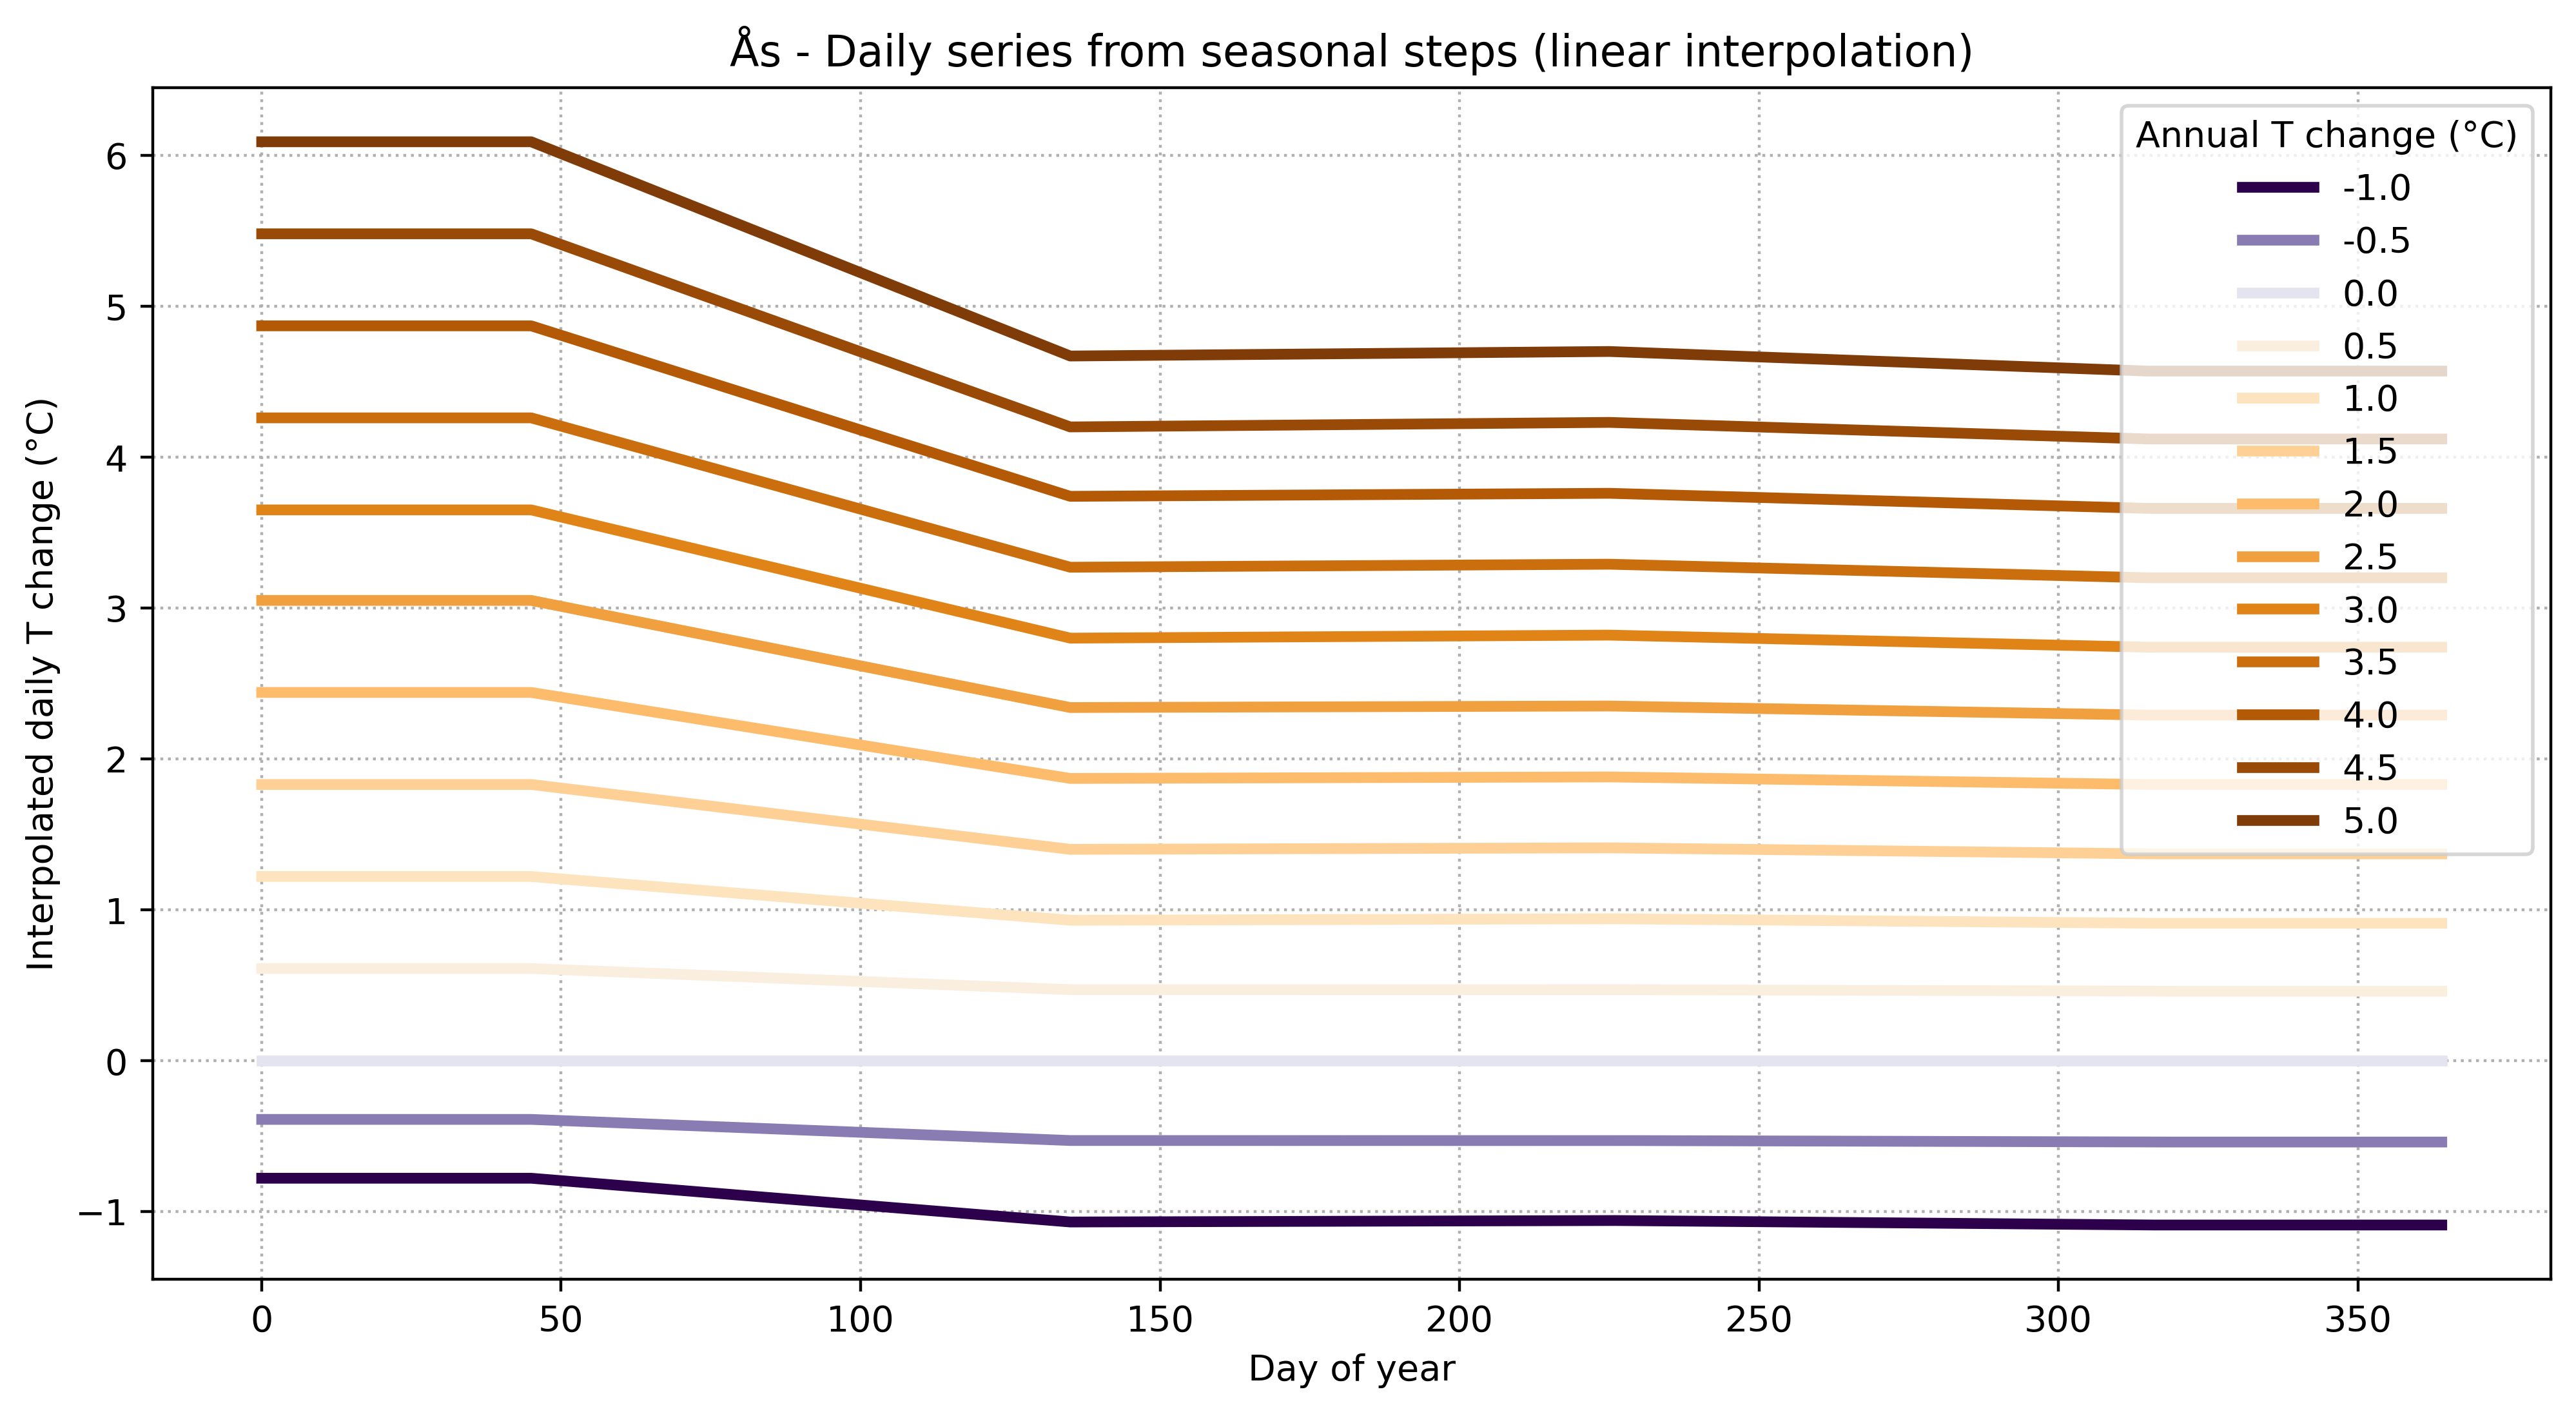

In [13]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define day-of-year anchors for seasonal centers
season_days = {
    "DJF": 45,   # mid-February
    "MAM": 135,  # mid-May
    "JJA": 225,  # mid-August
    "SON": 315   # mid-November
}

# Daily index
ndays = 365
x_days = np.arange(ndays)

# Interpolate each step row to daily series
daily_series_list = []
for idx, row in steps.iterrows():
    yvals = [row["DJF"], row["MAM"], row["JJA"], row["SON"]]
    xvals = [season_days[s] for s in ["DJF","MAM","JJA","SON"]]
    daily_series = np.interp(x_days, xvals, yvals)
    daily_series_list.append(daily_series)

# Plot a few examples
plt.figure(figsize=(12,6), dpi = 400)

# Create a colormap from blue to red, centered at i=2
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.3, vmax=12)  # indices range 0–12, center at 2
cmap = cm.get_cmap("PuOr_r")  # reversed RdBu: blue for low, red for high

for i in range(13):  # 0–12
    step = steps['Annual'][i]
    color = cmap(norm(i))
    plt.plot(x_days, daily_series_list[i], label=f"{step}", color=color, linewidth=3)

plt.xlabel("Day of year")
plt.ylabel("Interpolated daily T change (°C)")
plt.title("Ås - Daily series from seasonal steps (linear interpolation)")
plt.legend(title='Annual T change (°C)')
plt.grid(True, linestyle=':')
plt.show()

#### 2. Precipitation

In [14]:
################## rcp85 2071-2099 ##################
pr_rcp85 = pp.sel(rcp_tag='rcp85').mean(dim=['model_tag','rlon','rlat'])
data = pr_rcp85['pr'] * 86400  # Convert to mm/day
data = data.to_dataframe().reset_index().dropna(subset=["pr"])

# Add year and month
data["year"] = data["time"].dt.year
data["month"] = data["time"].dt.month

# --- Annual means (one value per year) ---
annual_means = (
    data.groupby(["year","rcp_tag"])["pr"]
    .mean()
    .reset_index()
)
annual_means["season"] = "Annual"
annual_means["time"] = pd.to_datetime(annual_means["year"].astype(str) + "-01-01")

# --- Seasonal means (one value per year per season) ---
# Define a "season_year" so DJF is grouped correctly
data["season_year"] = data["year"]
data.loc[data["month"] == 12, "season_year"] += 1  # December belongs to next year's DJF

def month_to_season(m):
    if m in [12,1,2]: return "DJF"
    elif m in [3,4,5]: return "MAM"
    elif m in [6,7,8]: return "JJA"
    elif m in [9,10,11]: return "SON"

data["season"] = data["month"].map(month_to_season)

seasonal_means = (
    data.groupby(["season_year","season","rcp_tag"])["pr"]
    .mean()
    .reset_index()
    .rename(columns={"season_year":"year"})
)
seasonal_means["time"] = pd.to_datetime(seasonal_means["year"].astype(str) + "-01-01")

# --- Combine annual + seasonal ---
data_means = pd.concat([annual_means, seasonal_means], ignore_index=True)

# --- Baseline climatology ---
start, end = baseline_period
baseline = data_means.query("time >= @start and time <= @end").copy()

seasonal_climatology = baseline.query("season != 'Annual'").groupby("season")["pr"].mean()
annual_climatology = baseline.query("season == 'Annual'")["pr"].mean()

# --- Last period anomalies ---
start, end = last_period
data_2071_2099 = data_means.query("time >= @start and time <= @end").copy()

def anomaly(row):
    if row["season"] == "Annual":
        return (row["pr"] - annual_climatology)/annual_climatology * 100 # Percentage change for annual
    else:
        return (row["pr"] - seasonal_climatology.loc[row["season"]])/seasonal_climatology.loc[row["season"]] * 100  # Percentage change for seasons

data_2071_2099["pr_change"] = data_2071_2099.apply(anomaly, axis=1)


################## all scenarios all periods ##################
pr_rcps = pp.mean(dim=['model_tag','rlon','rlat'])
data = pr_rcps['pr'] * 86400  # Convert to mm/day
data = data.to_dataframe().reset_index().dropna(subset=["pr"])

# Add year and month
data["year"] = data["time"].dt.year
data["month"] = data["time"].dt.month

# --- Annual means (one value per year per scenario) ---
annual_means = (
    data.groupby(["year","rcp_tag"])["pr"]
    .mean()
    .reset_index()
)
annual_means["season"] = "Annual"
annual_means["time"] = pd.to_datetime(annual_means["year"].astype(str) + "-01-01")

# --- Seasonal means (one value per year per season) ---
# Shift December into next year's DJF
data["season_year"] = data["year"]
data.loc[data["month"] == 12, "season_year"] += 1

def month_to_season(m):
    if m in [12,1,2]: return "DJF"
    elif m in [3,4,5]: return "MAM"
    elif m in [6,7,8]: return "JJA"
    elif m in [9,10,11]: return "SON"

data["season"] = data["month"].map(month_to_season)

seasonal_means = (
    data.groupby(["season_year","season","rcp_tag"])["pr"]
    .mean()
    .reset_index()
    .rename(columns={"season_year":"year"})
)
seasonal_means["time"] = pd.to_datetime(seasonal_means["year"].astype(str) + "-01-01")

# --- Combine annual + seasonal ---
data_means = pd.concat([annual_means, seasonal_means], ignore_index=True)

# --- Baseline climatology ---
start, end = baseline_period
baseline = data_means.query("time >= @start and time <= @end").copy()

seasonal_climatology = baseline.query("season != 'Annual'").groupby("season")["pr"].mean()
annual_climatology = baseline.query("season == 'Annual'")["pr"].mean()

# --- Collect anomalies for each scenario and period ---
results = []
for start, end in periods:
    sub = data_means.query("time >= @start and time <= @end").copy()
    sub["pr_change"] = sub.apply(
        lambda row: (row["pr"] - (annual_climatology if row["season"]=="Annual"
                                 else seasonal_climatology.loc[row["season"]])) / (annual_climatology if row["season"]=="Annual"
                                 else seasonal_climatology.loc[row["season"]]) * 100, # Percentage change
        axis=1
    )
    sub["period"] = f"{start[:4]}-{end[:4]}"
    results.append(sub)

all_data = pd.concat(results, ignore_index=True)

In [17]:
### Summary statistics for all RCPs and all periods 

max_all = np.max(all_data[all_data['season'] == 'Annual']["pr_change"])
min_all = np.min(all_data[all_data['season'] == 'Annual']["pr_change"])

print(f"Maximum annual pr_change (all RCPs, all periods): {max_all:.2f} %")
print(f"Minimum annual pr_change (all RCPs, all periods): {min_all:.2f} %")

# Use the percentiles to define the steps range

Maximum annual pr_change (all RCPs, all periods): 25.18 %
Minimum annual pr_change (all RCPs, all periods): -14.06 %


In [18]:
#create dataframe with columns: 'annual','DJF','MAM','JJA','SON' and rows with the weighted steps 
weight_DJF = np.mean(data_2071_2099[data_2071_2099['season']=='DJF']['pr_change']) - np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['pr_change'])
weight_MAM = np.mean(data_2071_2099[data_2071_2099['season']=='MAM']['pr_change']) - np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['pr_change'])
weight_JJA = np.mean(data_2071_2099[data_2071_2099['season']=='JJA']['pr_change']) - np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['pr_change'])
weight_SON = np.mean(data_2071_2099[data_2071_2099['season']=='SON']['pr_change']) - np.mean(data_2071_2099[data_2071_2099['season']=='Annual']['pr_change'])

steps = pd.DataFrame({
    "Annual": np.arange(-15, 40, 5),
    "DJF": np.round(np.arange(-15, 40, 5) + weight_DJF,2),
    "MAM": np.round(np.arange(-15, 40, 5) + weight_MAM,2),
    "JJA": np.round(np.arange(-15, 40, 5) + weight_JJA,2),
    "SON": np.round(np.arange(-15, 40, 5) + weight_SON,2)
})

steps[steps['Annual'] == 0] = 0
steps.to_excel('methodology_outs/pr_change_steps_weighted_seasons_JOK.xlsx', index=False)

In [20]:
steps

,Annual,DJF,MAM,JJA,SON
0,-15,1.14,-7.6,-30.08,-17.44
1,-10,6.14,-2.6,-25.08,-12.44
2,-5,11.14,2.4,-20.08,-7.44
3,0,0.00,0.0,0.00,0.00
4,5,21.14,12.4,-10.08,2.56
5,10,26.14,17.4,-5.08,7.56
6,15,31.14,22.4,-0.08,12.56
7,20,36.14,27.4,4.92,17.56
8,25,41.14,32.4,9.92,22.56
9,30,46.14,37.4,14.92,27.56


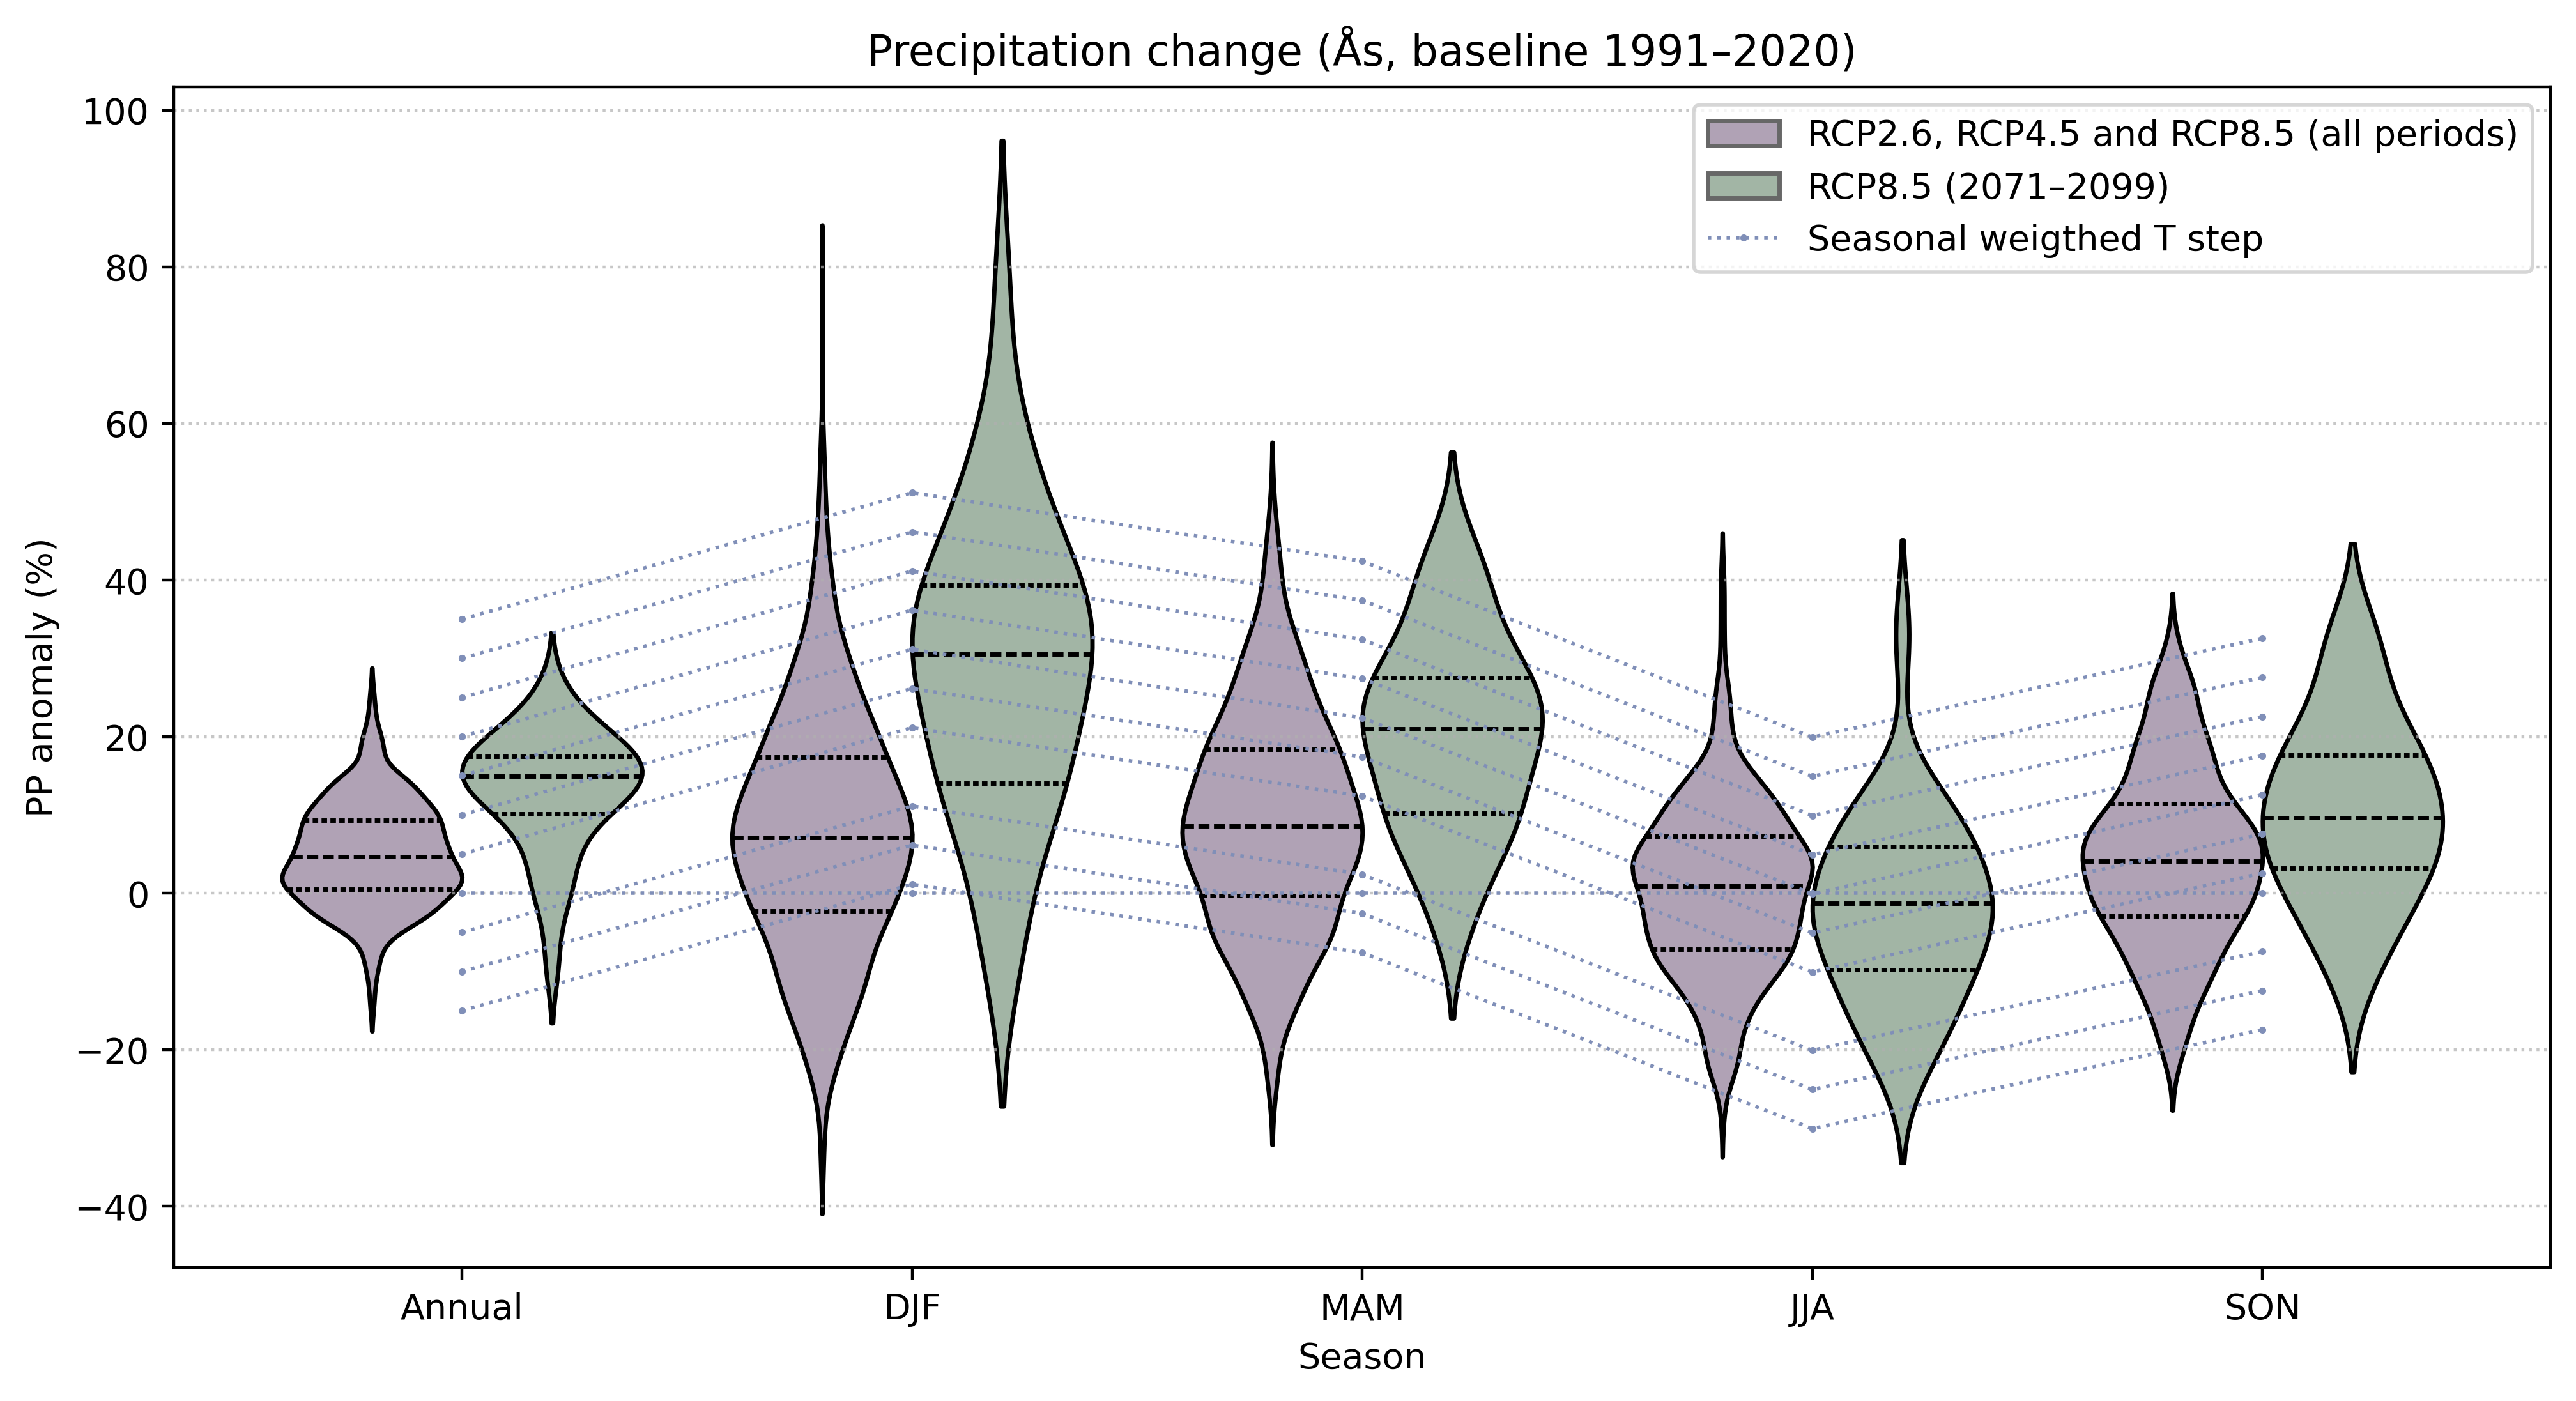

In [21]:
### plot
# Label each dataset
all_data_plot = all_data.copy()
all_data_plot["dataset"] = "RCP2.6, RCP4.5 and RCP8.5 (all periods)"

data_2071_2099_plot = data_2071_2099.copy()
data_2071_2099_plot["dataset"] = "RCP8.5 (2071–2099)"

# Combine
combined = pd.concat([all_data_plot, data_2071_2099_plot])

plt.figure(figsize=(12,6), dpi = 400)
plt.grid(linestyle=':', alpha=0.7)

ax = sns.violinplot( 
    x="season", y="pr_change", hue="dataset",
    data=combined,
    inner="quartile", density_norm="width",
    order=["Annual","DJF","MAM","JJA","SON"], 
    palette= ['#B29FB8', '#9FB8A3']
)

# Style borders and mean lines
for violin in ax.collections:
    violin.set_edgecolor("black")
for line in ax.lines:
    line.set_color("black")

season_order = ["Annual","DJF","MAM","JJA","SON"]
# Each row in steps is one "step index"
for idx, row in steps.iterrows():
    yvals = [row[season] for season in season_order]
    xvals = list(range(len(season_order)))  # [0,1,2,3,4]
    ax.plot(xvals, yvals, color='#808FB8', linewidth=1, linestyle = ':', marker="o", markersize=1, label = 'Seasonal weigthed T step' if idx == 0 else "")

plt.title("Precipitation change (Ås, baseline 1991–2020)")
plt.ylabel("PP anomaly (%)")
plt.xlabel("Season")
plt.legend(loc="best")
plt.show()

/var/folders/hh/pldtd_756y10knrbjp0j8jv80000gn/T/ipykernel_98650/2761024181.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("PuOr_r")  # reversed RdBu: blue for low, red for high


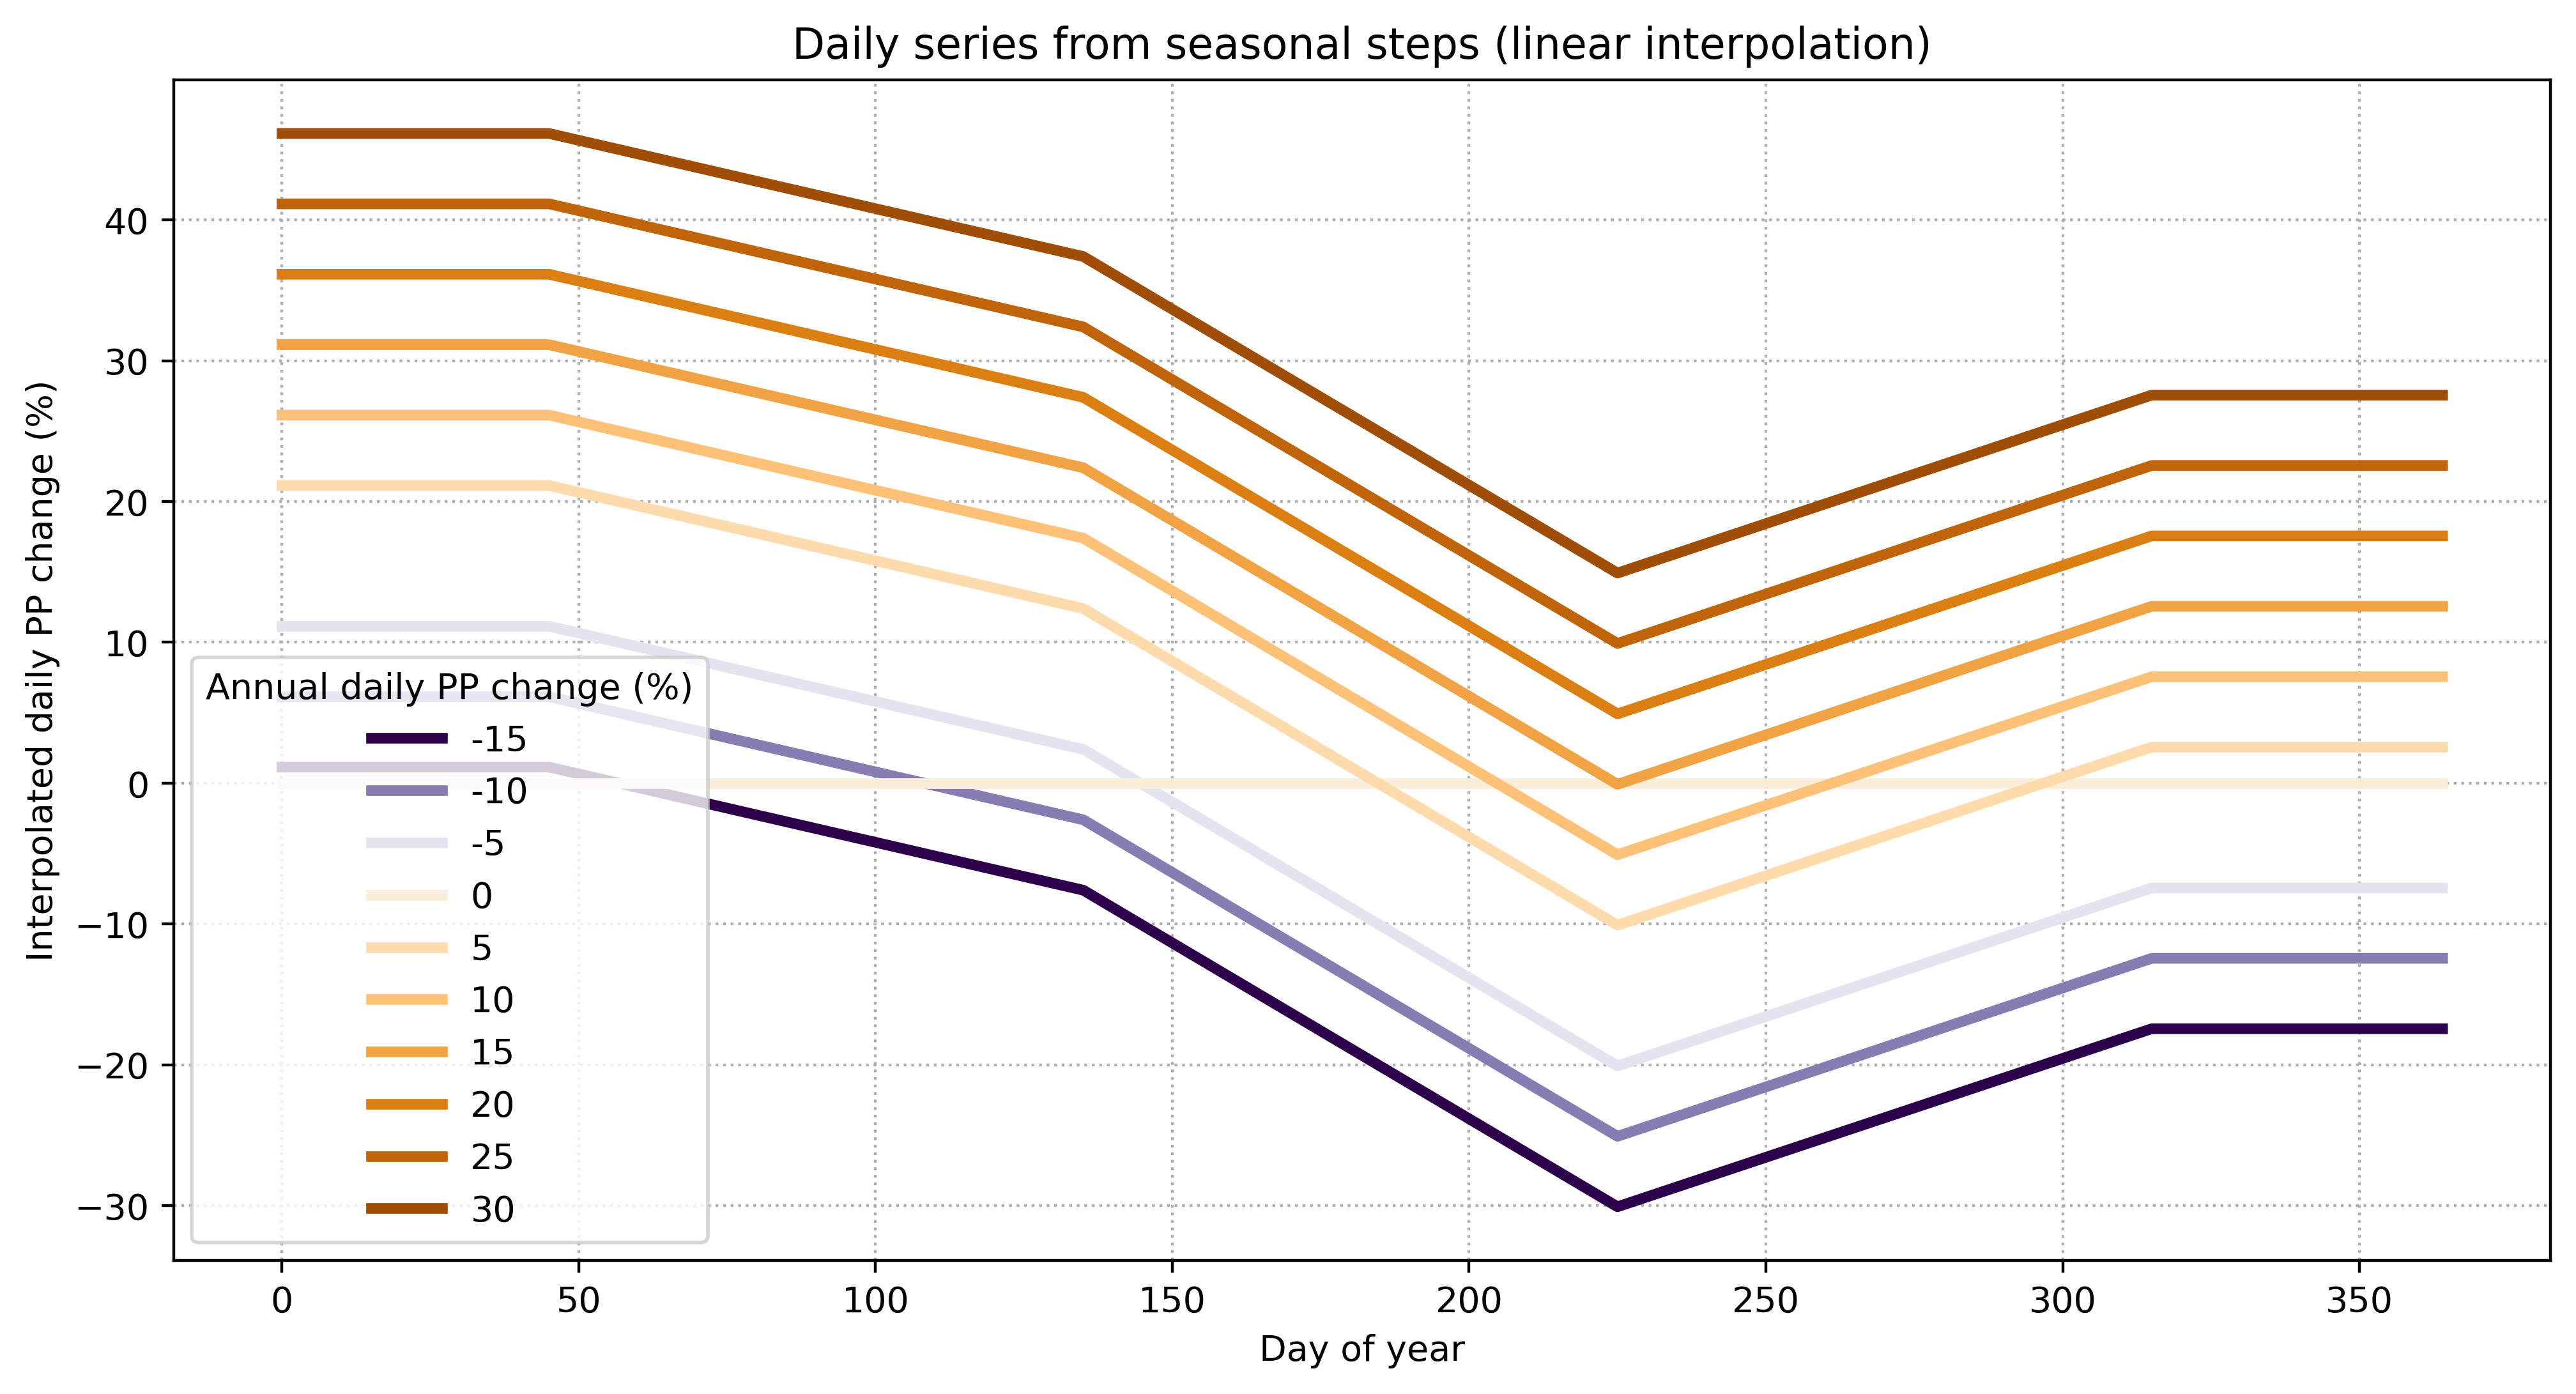

In [22]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define day-of-year anchors for seasonal centers
season_days = {
    "DJF": 45,   # mid-February
    "MAM": 135,  # mid-May
    "JJA": 225,  # mid-August
    "SON": 315   # mid-November
}

# Daily index
ndays = 365
x_days = np.arange(ndays)

# Interpolate each step row to daily series
daily_series_list = []
for idx, row in steps.iterrows():
    yvals = [row["DJF"], row["MAM"], row["JJA"], row["SON"]]
    xvals = [season_days[s] for s in ["DJF","MAM","JJA","SON"]]
    daily_series = np.interp(x_days, xvals, yvals)
    daily_series_list.append(daily_series)

# Plot a few examples
plt.figure(figsize=(12,6), dpi = 400)

# Create a colormap from blue to red, centered at i=2
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.3, vmax=10)  # indices range 0–12, center at 2
cmap = cm.get_cmap("PuOr_r")  # reversed RdBu: blue for low, red for high

for i in range(10):  # 0–12
    step = steps['Annual'][i]
    color = cmap(norm(i))
    plt.plot(x_days, daily_series_list[i], label=f"{step}", color=color, linewidth=3)

plt.xlabel("Day of year")
plt.ylabel("Interpolated daily PP change (%)")
plt.title("Daily series from seasonal steps (linear interpolation)")
plt.legend(title='Annual daily PP change (%)')
plt.grid(True, linestyle=':')
plt.show()